In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def payoff_estrategia(S_range, legs):
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
    return total

def graficar_estrategia(S_range, pnl, titulo, K_lines=None, S0=None):
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if S0:
        plt.axvline(S0, color='green', linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8, linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red', label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

def get_mid_price(df, strike):

    row = df[df['strike'] == strike]
    if not row.empty:
        return (row['bid'].iloc[0] + row['ask'].iloc[0]) / 2
    else:
        closest_idx = (df['strike'] - strike).abs().idxmin()
        return (df.loc[closest_idx, 'bid'] + df.loc[closest_idx, 'ask']) / 2

{'S0': 694.4600219726562, 'Butterfly': {'C1': 34.555, 'C2': 15.215, 'C3': 1.16, 'Costo': 5.285, 'GananciaMax': 14.715, 'PerdidaMax': -5.285}, 'IronCondor': {'Ps': 0.20500000000000002, 'Pl': 0.08499999999999999, 'Cs': 1.16, 'Cl': 0.035, 'PrimaCobrada': 1.245, 'GananciaMax': 1.245, 'PerdidaMax': 18.755}, 'CoveredCall': {'Prima': 1.16, 'GananciaMax': 6.69997802734375, 'BreakEven': 693.3000219726563}, 'ProtectivePut': {'Prima': 0.125, 'PerdidaMax': -44.58502197265625, 'BreakEven': 694.5850219726562}}


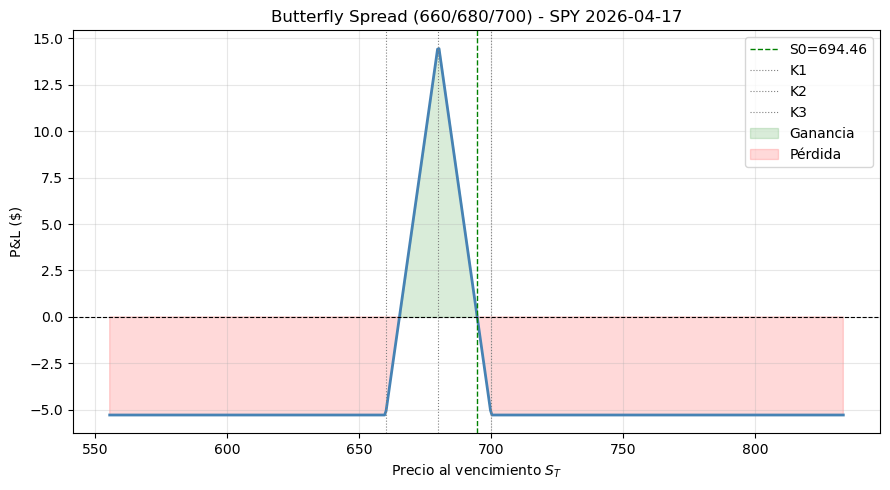

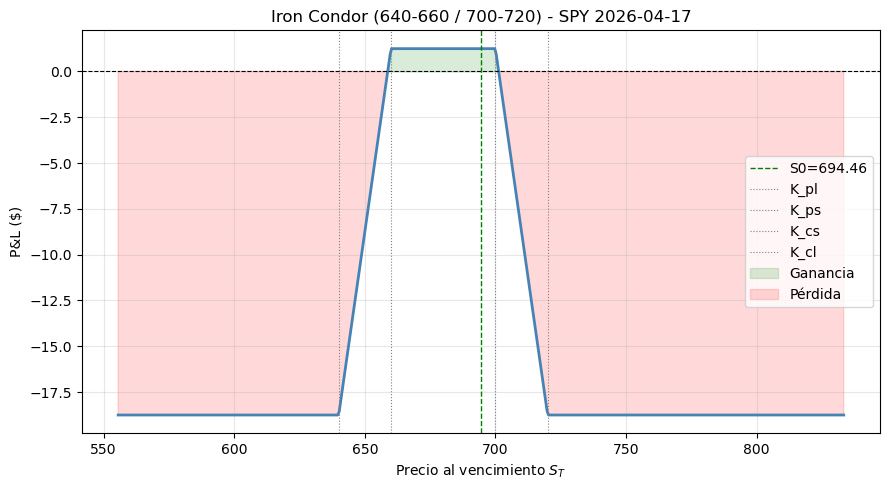

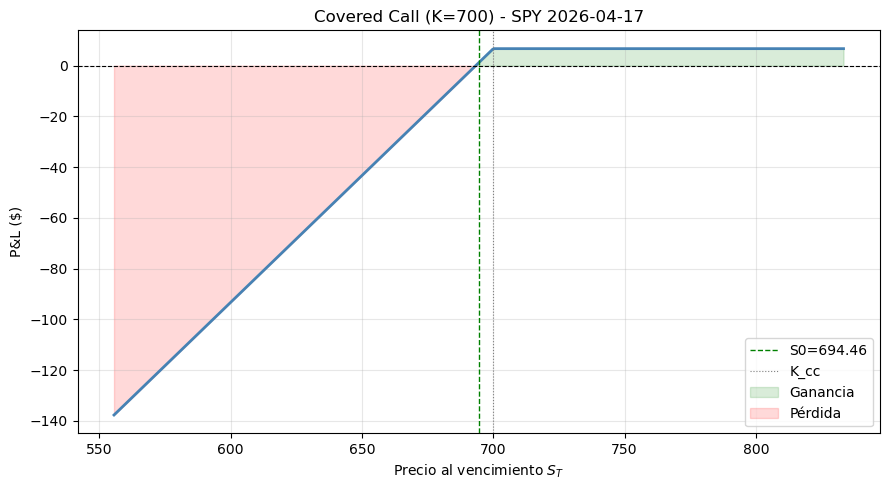

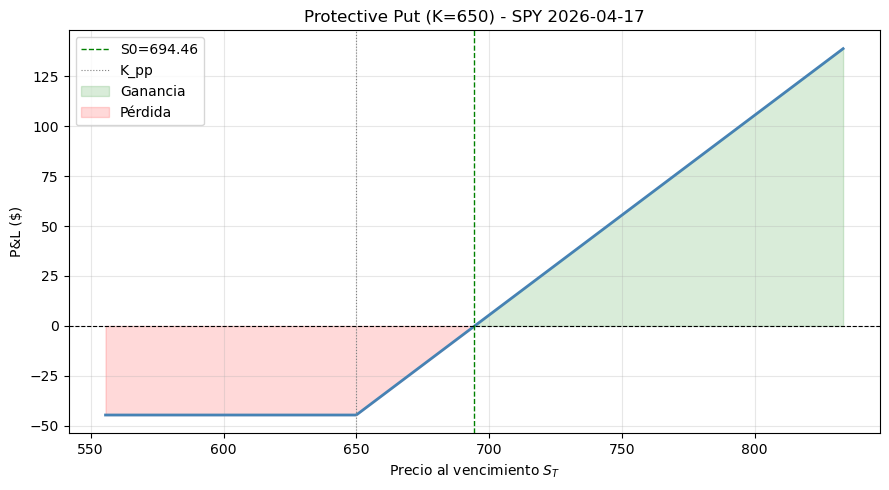

In [ ]:
spy = yf.Ticker("SPY")
S0 = spy.history(period="1d")['Close'].iloc[-1]
expiracion = "2026-04-17"
opt_chain = spy.option_chain(expiracion)
calls = opt_chain.calls
puts = opt_chain.puts
strikes_butterfly = [660, 680, 700]
C1 = get_mid_price(calls, 660)
C2 = get_mid_price(calls, 680)
C3 = get_mid_price(calls, 700)

strikes_condor = {'pl': 640, 'ps': 660, 'cs': 700, 'cl': 720}
P_l = get_mid_price(puts, 640)
P_s = get_mid_price(puts, 660)
C_s = get_mid_price(calls, 700)
C_l = get_mid_price(calls, 720)
K_cc = 700
C_cc = get_mid_price(calls, 700)
K_pp = 650
P_pp = get_mid_price(puts, 650)
S_range = np.linspace(S0 * 0.8, S0 * 1.2, 500)
legs_butterfly = [
    {'tipo': 'call', 'K': 660, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': 680, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': 700, 'prima': C3, 'posicion': +1},
]

pnl_butterfly = payoff_estrategia(S_range, legs_butterfly)
graficar_estrategia(S_range, pnl_butterfly, f'Butterfly Spread (660/680/700) - SPY {expiracion}',
                    K_lines=[(660, 'K1'), (680, 'K2'), (700, 'K3')], S0=S0)

plt.savefig('butterfly_payoff.png')
legs_condor = [

    {'tipo': 'put',  'K': 640, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': 660, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': 700, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': 720, 'prima': C_l, 'posicion': +1},
]

pnl_condor = payoff_estrategia(S_range, legs_condor)

graficar_estrategia(S_range, pnl_condor, f'Iron Condor (640-660 / 700-720) - SPY {expiracion}',
                    K_lines=[(640, 'K_pl'), (660, 'K_ps'), (700, 'K_cs'), (720, 'K_cl')], S0=S0)

plt.savefig('iron_condor_payoff.png')
pnl_accion = S_range - S0
legs_cc = [{'tipo': 'call', 'K': K_cc, 'prima': C_cc, 'posicion': -1}]
pnl_covered = pnl_accion + payoff_estrategia(S_range, legs_cc)
graficar_estrategia(S_range, pnl_covered, f'Covered Call (K=700) - SPY {expiracion}',

                    K_lines=[(K_cc, 'K_cc')], S0=S0)

plt.savefig('covered_call_payoff.png')
legs_pp = [{'tipo': 'put', 'K': K_pp, 'prima': P_pp, 'posicion': +1}]
pnl_protective = pnl_accion + payoff_estrategia(S_range, legs_pp)
graficar_estrategia(S_range, pnl_protective, f'Protective Put (K=650) - SPY {expiracion}',

                    K_lines=[(K_pp, 'K_pp')], S0=S0)

plt.savefig('protective_put_payoff.png')
resumen = {

    'S0': S0,

    'Butterfly': {
        'C1': C1, 'C2': C2, 'C3': C3,
        'Costo': C1 - 2*C2 + C3,
        'GananciaMax': (680-660) - (C1 - 2*C2 + C3),
        'PerdidaMax': -(C1 - 2*C2 + C3)

    },

    'IronCondor': {
        'Ps': P_s, 'Pl': P_l, 'Cs': C_s, 'Cl': C_l,
        'PrimaCobrada': (P_s - P_l) + (C_s - C_l),
        'GananciaMax': (P_s - P_l) + (C_s - C_l),
        'PerdidaMax': (660-640) - ((P_s - P_l) + (C_s - C_l))

    },

    'CoveredCall': {
        'Prima': C_cc,
        'GananciaMax': (K_cc - S0) + C_cc,
        'BreakEven': S0 - C_cc
    },

    'ProtectivePut': {
        'Prima': P_pp,
        'PerdidaMax': -(S0 - K_pp + P_pp),
        'BreakEven': S0 + P_pp
    }

}

print(resumen)

#### **Preguntas**


1. Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?

El iron Condor ya que dentro de estos precios (660 a 700) nosotros ganamos 

2. Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.

El peor escenario para tu iron condor es que haya mucha volatilidad implicita y no, no lo hace una estrategia sin riesgo por que si el SPY sube o baja mucho pierdes tu prima o hasta pierdes de tu cartera dependiendo del caso, y la perdida maxima es de 720-700 -0.55=19.45 por contrato, recordemos que lo minimo son 100 contratos asi que $1,945 dolares 

3. Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.

Depende las primas, si los vendedores de opciones por pura suerte estan en la lela y no te cobran unas primas altisimas por la IV tan alta, un straddle pero en un caso realista, el iron condor ya que con una volatilidad tan alta puedes poner una prima altisima y puedes hacer un delta-gamma hedging, si hablamos en terminos de vega y theta la theta(factor de decaimiento) nos apoyaria bastante el hecho que el IV es tan alto para que sea mas agresivo la depreciacion de la opcion y de Vega la opcion suele tener su punto cuspide de volatilidad por entrega de resultados o alguna politica monetaria, al salir el comunicado o los resultados, el volatility crush nos apoyaria a que se regule la volatilidad.

4. El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.

La razon 1 es por que obtienes una prima asi que si sube obtienes la ganacia de tu accion y las primas, por otra razon seria que te estas cubriendo ante perdidas del precio

5. Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".

Si tu compras un coche(una accion), le compras un seguro por si cochas(baja la accion) para que no sea una perdida total, solo pagas la prima que depende del seguro pero pongamos que un 15% del costo de la pieza (prima que recibe), lo que cambia es por ejemplo que aca tu pagas la prima y ya estas asegurado, en los seguros compras un seguro y si chocas aparte tienes que pagar el deducible que depende cual fue la perdida o lo chocado.

6. ¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.

En el butterfly necesitas ser mucho mas preciso con el precio para la ganacia maxima, en el iron condor esta topado de 660 a 700 por lo que en uno tienes una ganacia mucho mas alta pero necesita mucha perfeccion y en el otro tienes mas ancho de banda o puedes asumir mas error en tus calculos

7. Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?

Si la IV cae, el valor de tu estrategia sube por que nosotros queremos calma y que se quede estable el mercado. si hubiera subido tu estrategia bajaria de precio por la inquietud de tu mercado